## This Notebook gives an example on how plot estimated CAG expansion and Aggregate correlation with different protein readouts (Figure 6 and Supplementary Figure 16 in the manuscript)

In [1]:
import scanpy as sc
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

In [2]:
adata=sc.read_h5ad('adata/Dryad/adata_AGG_CAG.h5ad')

In [3]:
#Estimated Mean CAG

adata.obs['CAG_length'] = [
    (cag_level - 0.0464) / 0.0024 if batch == 'Aug' else (cag_level - 0.0462) / 0.003
    for cag_level, batch in zip(adata.obs['CAG'], adata.obs['batch'])
]

In [4]:
wt_allele = {
    "C1": 30, "C3": 19, "C4": 19, "C5": 17,
    "H1": 22, "H2": 20, "H3": 19, "H4": 20, "H5": 19
}

In [5]:
#Estimated Mutant CAG

for pt in adata.obs['patient'].unique():
    if pt in wt_allele:
        mask = adata.obs['patient'] == pt
        adata.obs.loc[mask, "CAG_mut"] = (
            adata.obs.loc[mask, "CAG_length"] * 2 - wt_allele[pt]
        )

In [6]:
for pt in adata.obs['patient'].unique():
    df = adata[adata.obs['patient'] == pt]
    print(f'{pt} CAG level: {np.mean(df.obs["CAG_mut"])}')

H1 CAG level: 49.54375806037704
H2 CAG level: 44.05922947150206
H4 CAG level: 55.91727695884768
C1 CAG level: 15.112511301120255
C3 CAG level: 21.81630464126221
H3 CAG level: 54.14808860076721
H5 CAG level: 58.86483817714501
C4 CAG level: 18.989591508764796
C5 CAG level: 21.096554912708083


In [7]:
Exc=adata[adata.obs['cluster_general']=='Excitatory Neurons'].copy()
Exc

AnnData object with n_obs × n_vars = 36855 × 1128
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CAG', 'nHTT', 'vol_nuc', 'sample', 'HD', 'patient', 'batch', 'cluster_names', 'Agg', 'Agg_bright', 'Agg_vol', 'Agg_x', 'Agg_y', 'Agg_z', 'Agg_dist', 'cluster_general', 'lipo', 'm_gamma', 'v_gamma', 'm_h3k9', 'm_h3k27', 'CAG_length', 'CAG_mut'
    obsm: 'X_pca', 'X_pca_harmony', 'X_raw', 'X_spatial', 'X_umap'

In [8]:
upatientHD = ['H1', 'H2', 'H4', 'H3', 'H5']
upatientHD_aug = ['H1', 'H2', 'H4']

In [9]:
##################################################
#### FIGURE 6B: GammaH2AX and Inclusions
##################################################

Global comparison Agg vs NoAgg: p = 0.0000


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


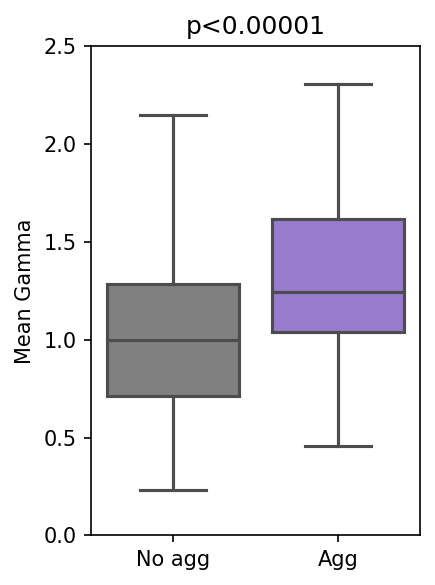

In [10]:
df_all = []

for pt in upatientHD_aug:

    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
    
    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)
    baseline = df_pt.loc[df_pt['Agg']==False, 'm_gamma'].median()
    df_pt['m_gamma_norm'] = df_pt['m_gamma'] / baseline 
    df_pt['patient'] = pt
    
    df_all.append(df_pt[['patient','Agg','m_gamma_norm', 'cluster_names']])

df_all = pd.concat(df_all)

no_agg = df_all.loc[df_all['Agg'] == False, 'm_gamma_norm']
agg    = df_all.loc[df_all['Agg'] == True, 'm_gamma_norm']

stat, pval = stats.ttest_ind(no_agg, agg, equal_var=False, nan_policy="omit")

print(f"Global comparison Agg vs NoAgg: p = {pval:.4f}")

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_all, x='Agg', y='m_gamma_norm',
                 showfliers=False, palette=['gray','mediumpurple'])
#sns.swarmplot(data=df_all, x='Agg', y='m_gamma_norm', color='black', size=2, alpha=0.6)

plt.ylabel("Mean Gamma")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
if pval>0.00001:
    plt.title(f'p={pval:.4f}')
else:
    plt.title(f'p<0.00001')
plt.ylim(0,2.5)

plt.tight_layout()
plt.savefig('Figures/F6B.pdf')
plt.show()

In [11]:
##################################################
#### SUPPLEMENTARY FIGURE 16A: GammaH2AX and Inclusions per donor
##################################################

Number of patients: 3
Paired t-test per patient median Agg vs NoAgg: p = 0.053215


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

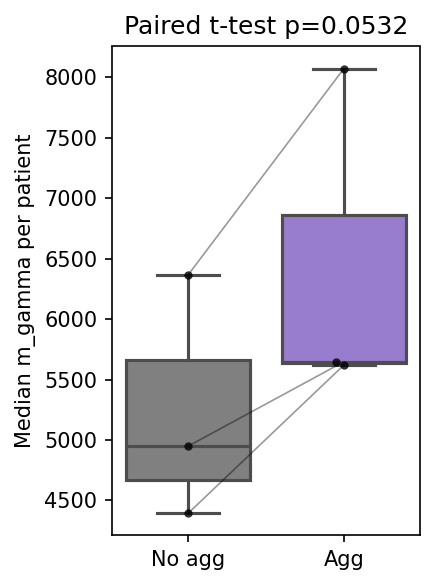

In [12]:
###PAIRED T TEST
agg_medians = []
noagg_medians = []

for pt in upatientHD_aug:
    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
        
    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)
    
    # Compute median for each condition within patient
    no_agg_median = df_pt.loc[df_pt['Agg'] == False, 'm_gamma'].median()
    agg_median    = df_pt.loc[df_pt['Agg'] == True,  'm_gamma'].median()
    
    # Only include patients with both conditions
    if not np.isnan(no_agg_median) and not np.isnan(agg_median):
        noagg_medians.append(no_agg_median)
        agg_medians.append(agg_median)

# Convert to arrays for t-test
noagg_medians = np.array(noagg_medians)
agg_medians = np.array(agg_medians)

# Paired t-test since values are matched per patient
stat, pval = stats.ttest_rel(noagg_medians, agg_medians, nan_policy="omit")

print("Number of patients:", len(noagg_medians))
print(f"Paired t-test per patient median Agg vs NoAgg: p = {pval:.6f}")

df_plot = pd.DataFrame({
    'NoAgg': noagg_medians,
    'Agg': agg_medians
}, index=upatientHD[:len(noagg_medians)])  # optional: match names

df_plot_melt = df_plot.reset_index().melt(id_vars='index', var_name='Condition', value_name='m_gamma')

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_plot_melt, x='Condition', y='m_gamma', 
                 showfliers=False, palette=['gray','mediumpurple'])
sns.swarmplot(data=df_plot_melt, x='Condition', y='m_gamma',
              color='black', size=4, alpha=0.8)

# optional: connect paired points
for i, row in df_plot.iterrows():
    plt.plot(['NoAgg','Agg'], row.values, color='black', alpha=0.4, linewidth=0.8)

plt.ylabel("Median m_gamma per patient")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
plt.title(f'Paired t-test p={pval:.4f}')
plt.savefig(f'Figures/F6C.pdf')
plt.tight_layout()
plt.show()


In [13]:
##################################################
#### SUPPLEMENTARY FIGURE 16G: GammaH2AX and Inclusions per cell type
##################################################

In [14]:
ucluster =  df_all['cluster_names'].unique()
ucluster

['L5.ET', 'L5.IT', 'L3.IT', 'L4.IT', 'L6.IT', 'L6.Car3', 'L2.IT', 'L6b', 'L6.CT', 'L5.6.NP']
Categories (10, object): ['L2.IT', 'L3.IT', 'L4.IT', 'L5.6.NP', ..., 'L6.CT', 'L6.Car3', 'L6.IT', 'L6b']

Global comparison Agg vs NoAgg: p = nan


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Ola

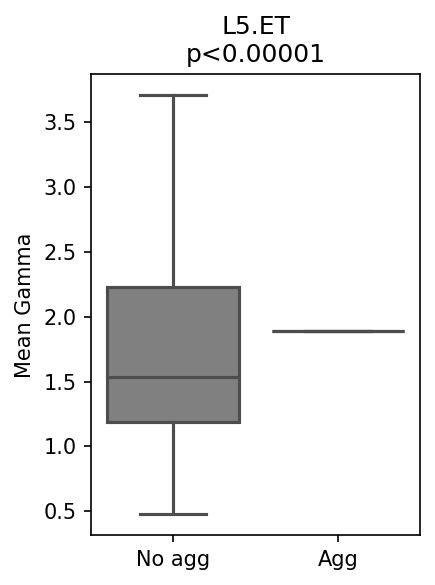

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Global comparison Agg vs NoAgg: p = 0.0005


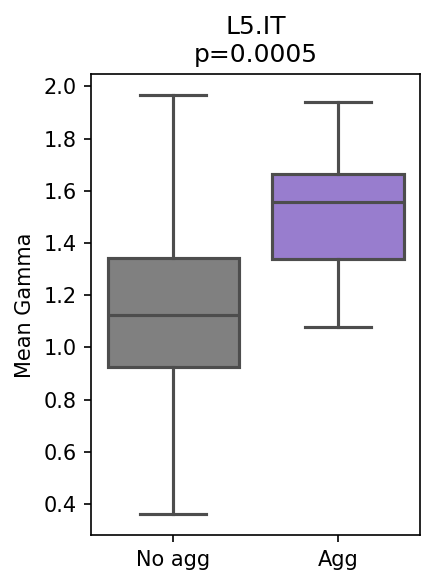

Global comparison Agg vs NoAgg: p = 0.3283


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


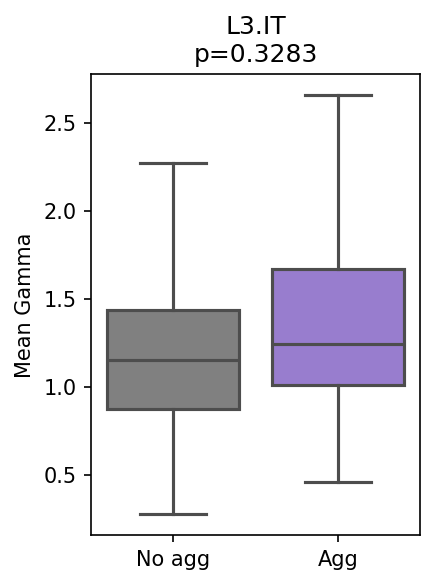

Global comparison Agg vs NoAgg: p = 0.0602


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


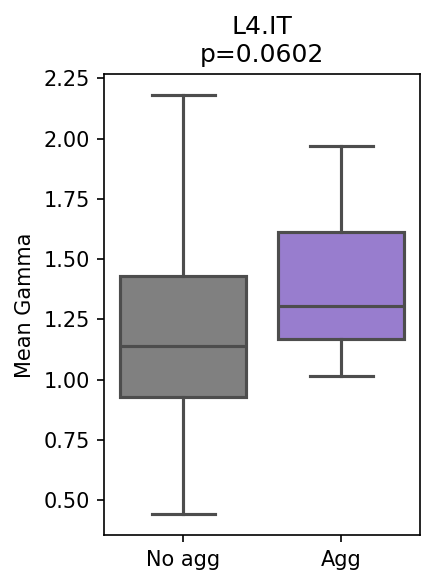

Global comparison Agg vs NoAgg: p = 0.1764


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


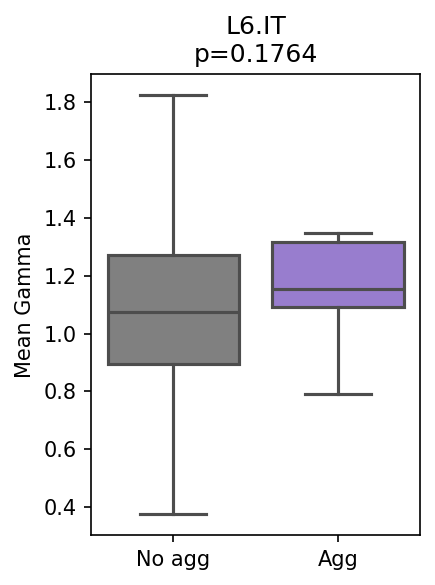

Global comparison Agg vs NoAgg: p = nan


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


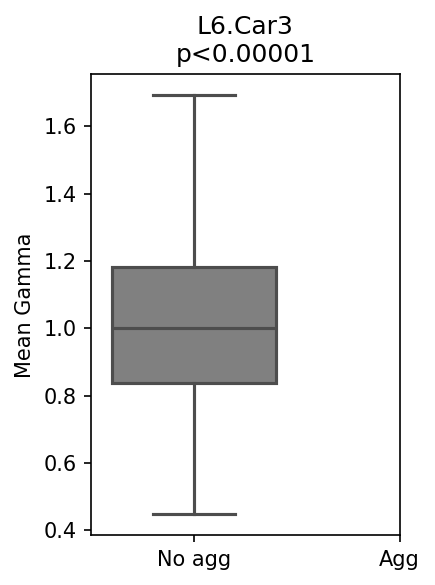

Global comparison Agg vs NoAgg: p = 0.0130


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


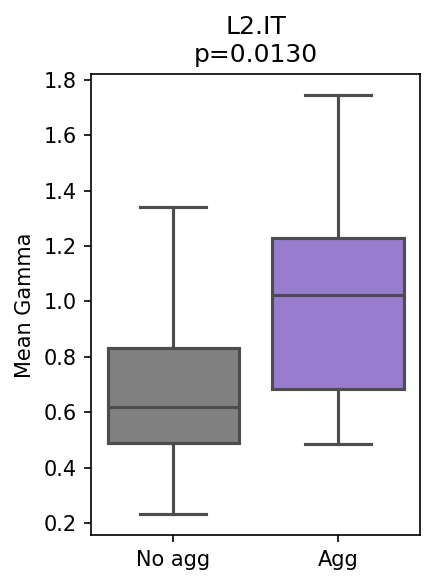

Global comparison Agg vs NoAgg: p = 0.0331


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


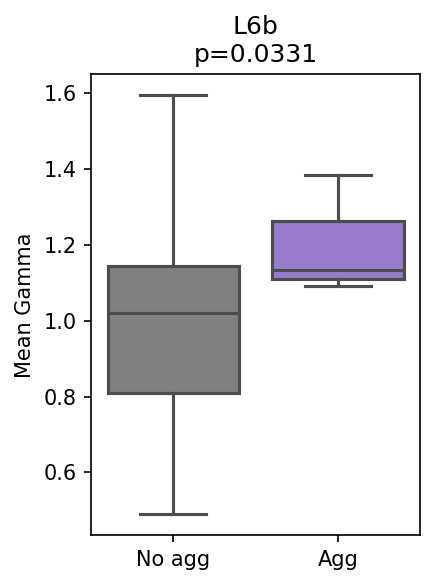

Global comparison Agg vs NoAgg: p = 0.6247


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


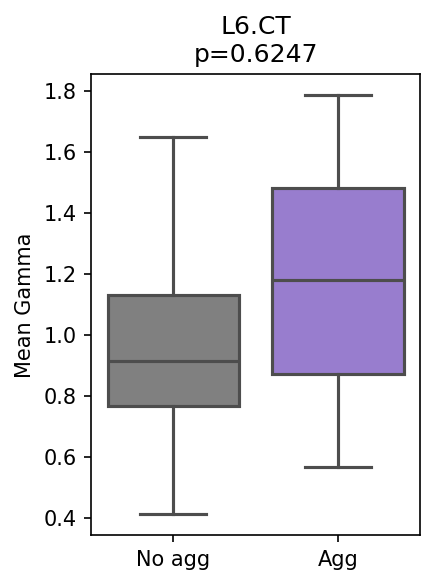

Global comparison Agg vs NoAgg: p = nan


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


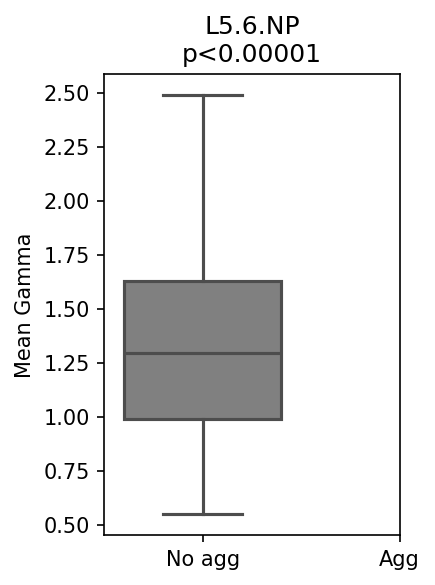

In [15]:
for cl in ucluster:
    cl_df_all =  df_all[df_all['cluster_names']==cl].copy()
    no_agg = cl_df_all.loc[cl_df_all['Agg'] == False, 'm_gamma_norm']
    agg    = cl_df_all.loc[cl_df_all['Agg'] == True, 'm_gamma_norm']
    
    stat, pval = stats.ttest_ind(no_agg, agg, equal_var=False, nan_policy="omit")
    
    print(f"Global comparison Agg vs NoAgg: p = {pval:.4f}")
    
    plt.figure(figsize=(3,4), dpi=150)
    ax = sns.boxplot(data=cl_df_all, x='Agg', y='m_gamma_norm', 
                 showfliers=False, palette=['gray','mediumpurple'])
    #sns.swarmplot(data=cl_df_all, x='Agg', y='m_gamma_norm', color='black', size=2, alpha=0.6)

    
    plt.ylabel("Mean Gamma")
    plt.xlabel('')
    plt.xticks([0,1], ['No agg','Agg'])
    if pval>0.00001:
        plt.title(f'{cl}\np={pval:.4f}')
    else:
        plt.title(f'{cl}\np<0.00001')
    #plt.ylim(0,4)
    
    plt.tight_layout()
    plt.savefig(f'Figures/SF16{cl}D_.pdf')
    plt.show()

In [16]:
##################################################
#### FIGURE 6D: GammaH2AX and CAG
##################################################

In [17]:
bins = [0, 50, 150, 250, 350, 450, np.inf]
bin_labels = ['<50', '50-150', '150-250', '250-350', '350-450', '>450']

In [18]:
def pval_to_star(pval):
    if pval < 1e-4:
        return '****'
    elif pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'


In [19]:
Exc5 = Exc[Exc.obs['nHTT']>5].copy()

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/4207852694.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_across = df.groupby('CAG_bin')['m_gamma_norm'].mean().reindex(bin_labels)
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/4207852694.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sem_across = df.groupby('CAG_bin')['m_gamma_norm'].sem().reindex(bin_labels)


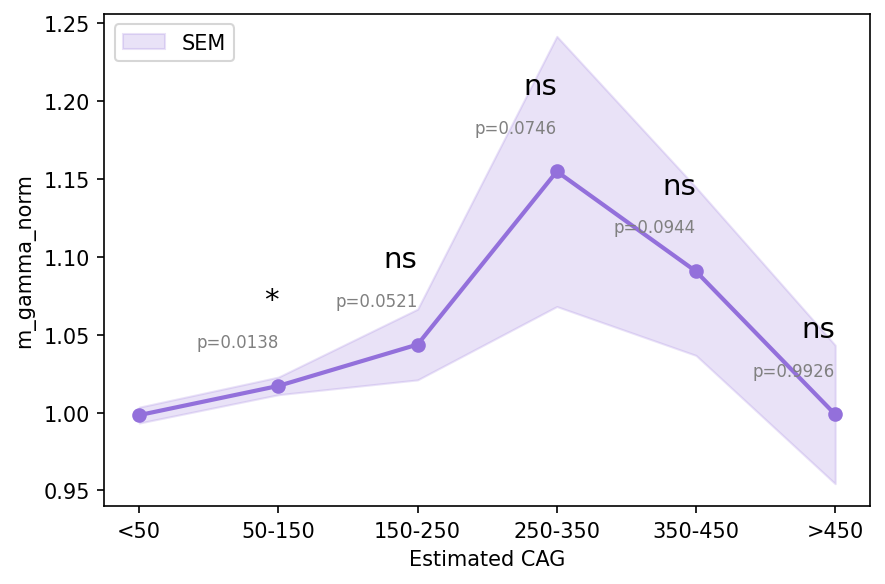

In [20]:
df = []

# Plot individual patient trajectories
for pt in upatientHD:
    df_pt = Exc5.obs[Exc5.obs['patient'] == pt].copy()

    baseline = df_pt.loc[df_pt['CAG_mut'] < 50, 'm_gamma'].mean()
    df_pt['m_gamma_norm'] = df_pt['m_gamma'] / baseline
    df_pt['CAG_bin'] = pd.cut(df_pt['CAG_mut'], bins=bins, labels=bin_labels, right=False)
    df.append(df_pt[['patient','CAG_mut','CAG_bin','m_gamma_norm', 'cluster_names']])

df = pd.concat(df)

# Compute mean ± SEM at the cell level
mean_across = df.groupby('CAG_bin')['m_gamma_norm'].mean().reindex(bin_labels)
sem_across = df.groupby('CAG_bin')['m_gamma_norm'].sem().reindex(bin_labels)

# Plot
plt.figure(figsize=(6,4), dpi=150)
plt.plot(bin_labels, mean_across, marker='o', color='mediumpurple', linewidth=2)
plt.fill_between(bin_labels,
                 mean_across - sem_across,
                 mean_across + sem_across,
                 color='mediumpurple', alpha=0.2, label='SEM')

# Reference bin = first one
ref_bin = bin_labels[0]
ref_values = df.loc[df['CAG_bin'] == ref_bin, 'm_gamma_norm'].dropna()

# T-test against each other bin using cell-level data
for i, bin_lab in enumerate(bin_labels[1:], start=1):
    group_values = df.loc[df['CAG_bin'] == bin_lab, 'm_gamma_norm'].dropna()
    if len(ref_values) > 1 and len(group_values) > 1:
        stat, pval = stats.ttest_ind(ref_values, group_values, equal_var=False)
        star = pval_to_star(pval)
        y_pos = mean_across.iloc[i] + 0.05
        plt.text(i, y_pos, star, ha='right', fontsize=14, color='black')
        plt.text(i, y_pos - 0.025, f"p={pval:.4f}", ha='right', fontsize=8, color='gray')

plt.ylabel("m_gamma_norm")
plt.xlabel("Estimated CAG")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f'Figures/F6C.pdf')
plt.show()


In [21]:
##################################################
#### FIGURE 6E: H3K9me3 and Inclusions
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Global comparison Agg vs NoAgg: p = 0.0000


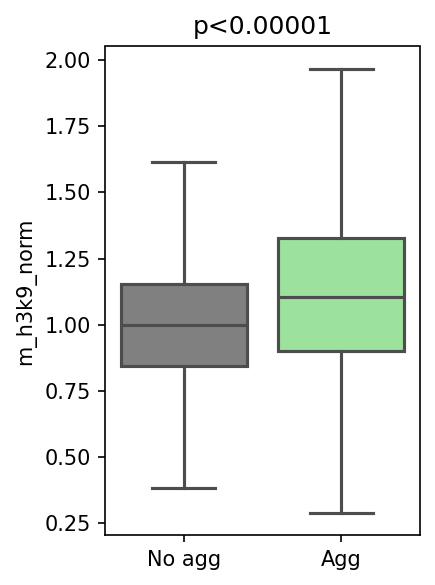

In [22]:
df_all = []

for pt in upatientHD:

    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
    
    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)
    baseline = df_pt.loc[df_pt['Agg']==False, 'm_h3k9'].median()
    df_pt['m_h3k9_norm'] = df_pt['m_h3k9'] / baseline 
    df_pt['patient'] = pt
    
    df_all.append(df_pt[['patient','Agg','m_h3k9_norm', 'cluster_names']])

df_all = pd.concat(df_all)

no_agg = df_all.loc[df_all['Agg'] == False, 'm_h3k9_norm']
agg    = df_all.loc[df_all['Agg'] == True, 'm_h3k9_norm']

stat, pval = stats.ttest_ind(no_agg, agg, equal_var=False, nan_policy="omit")

print(f"Global comparison Agg vs NoAgg: p = {pval:.4f}")

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_all, x='Agg', y='m_h3k9_norm',
                 showfliers=False, palette=['gray','lightgreen'])
#sns.swarmplot(data=df_all, x='Agg', y='m_h3k9_norm', color='black', size=2, alpha=0.6)

plt.ylabel("m_h3k9_norm")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
if pval>0.00001:
    plt.title(f'p={pval:.4f}')
else:
    plt.title(f'p<0.00001')
#plt.ylim(0,2.5)

plt.tight_layout()
plt.savefig(f'Figures/F6E_1.pdf')

#plt.savefig('Figures/F6B.pdf')
plt.show()


In [23]:
##################################################
#### SUPPLEMENTARY FIGURE 16B: H3K9me3 and Inclusions per donor
##################################################

Number of patients: 5
Paired t-test per patient median Agg vs NoAgg: p = 0.087313


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

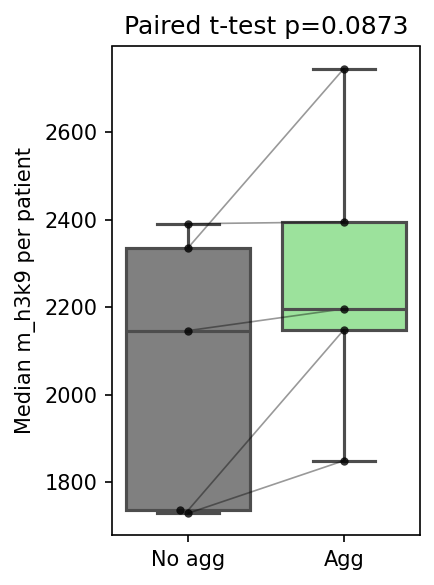

In [24]:
###PAIRED T TEST
agg_medians = []
noagg_medians = []

for pt in upatientHD:
    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()

    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)

    
    # Compute median for each condition within patient
    no_agg_median = df_pt.loc[df_pt['Agg'] == False, 'm_h3k9'].median()
    agg_median    = df_pt.loc[df_pt['Agg'] == True,  'm_h3k9'].median()
    
    # Only include patients with both conditions
    if not np.isnan(no_agg_median) and not np.isnan(agg_median):
        noagg_medians.append(no_agg_median)
        agg_medians.append(agg_median)

# Convert to arrays for t-test
noagg_medians = np.array(noagg_medians)
agg_medians = np.array(agg_medians)

# Paired t-test since values are matched per patient
stat, pval = stats.ttest_rel(noagg_medians, agg_medians, nan_policy="omit")

print("Number of patients:", len(noagg_medians))
print(f"Paired t-test per patient median Agg vs NoAgg: p = {pval:.6f}")

df_plot = pd.DataFrame({
    'NoAgg': noagg_medians,
    'Agg': agg_medians
}, index=upatientHD[:len(noagg_medians)])  # optional: match names

df_plot_melt = df_plot.reset_index().melt(id_vars='index', var_name='Condition', value_name='m_h3k9')

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_plot_melt, x='Condition', y='m_h3k9', 
                 showfliers=False, palette=['gray','lightgreen'])
sns.swarmplot(data=df_plot_melt, x='Condition', y='m_h3k9',
              color='black', size=4, alpha=0.8)

# optional: connect paired points
for i, row in df_plot.iterrows():
    plt.plot(['NoAgg','Agg'], row.values, color='black', alpha=0.4, linewidth=0.8)

plt.ylabel("Median m_h3k9 per patient")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
plt.title(f'Paired t-test p={pval:.4f}')
plt.tight_layout()
plt.savefig(f'Figures/F6E.pdf')

plt.show()


In [25]:
##################################################
#### SUPPLEMENTARY FIGURE 16H: H3K9me3 and Inclusions per cell type
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

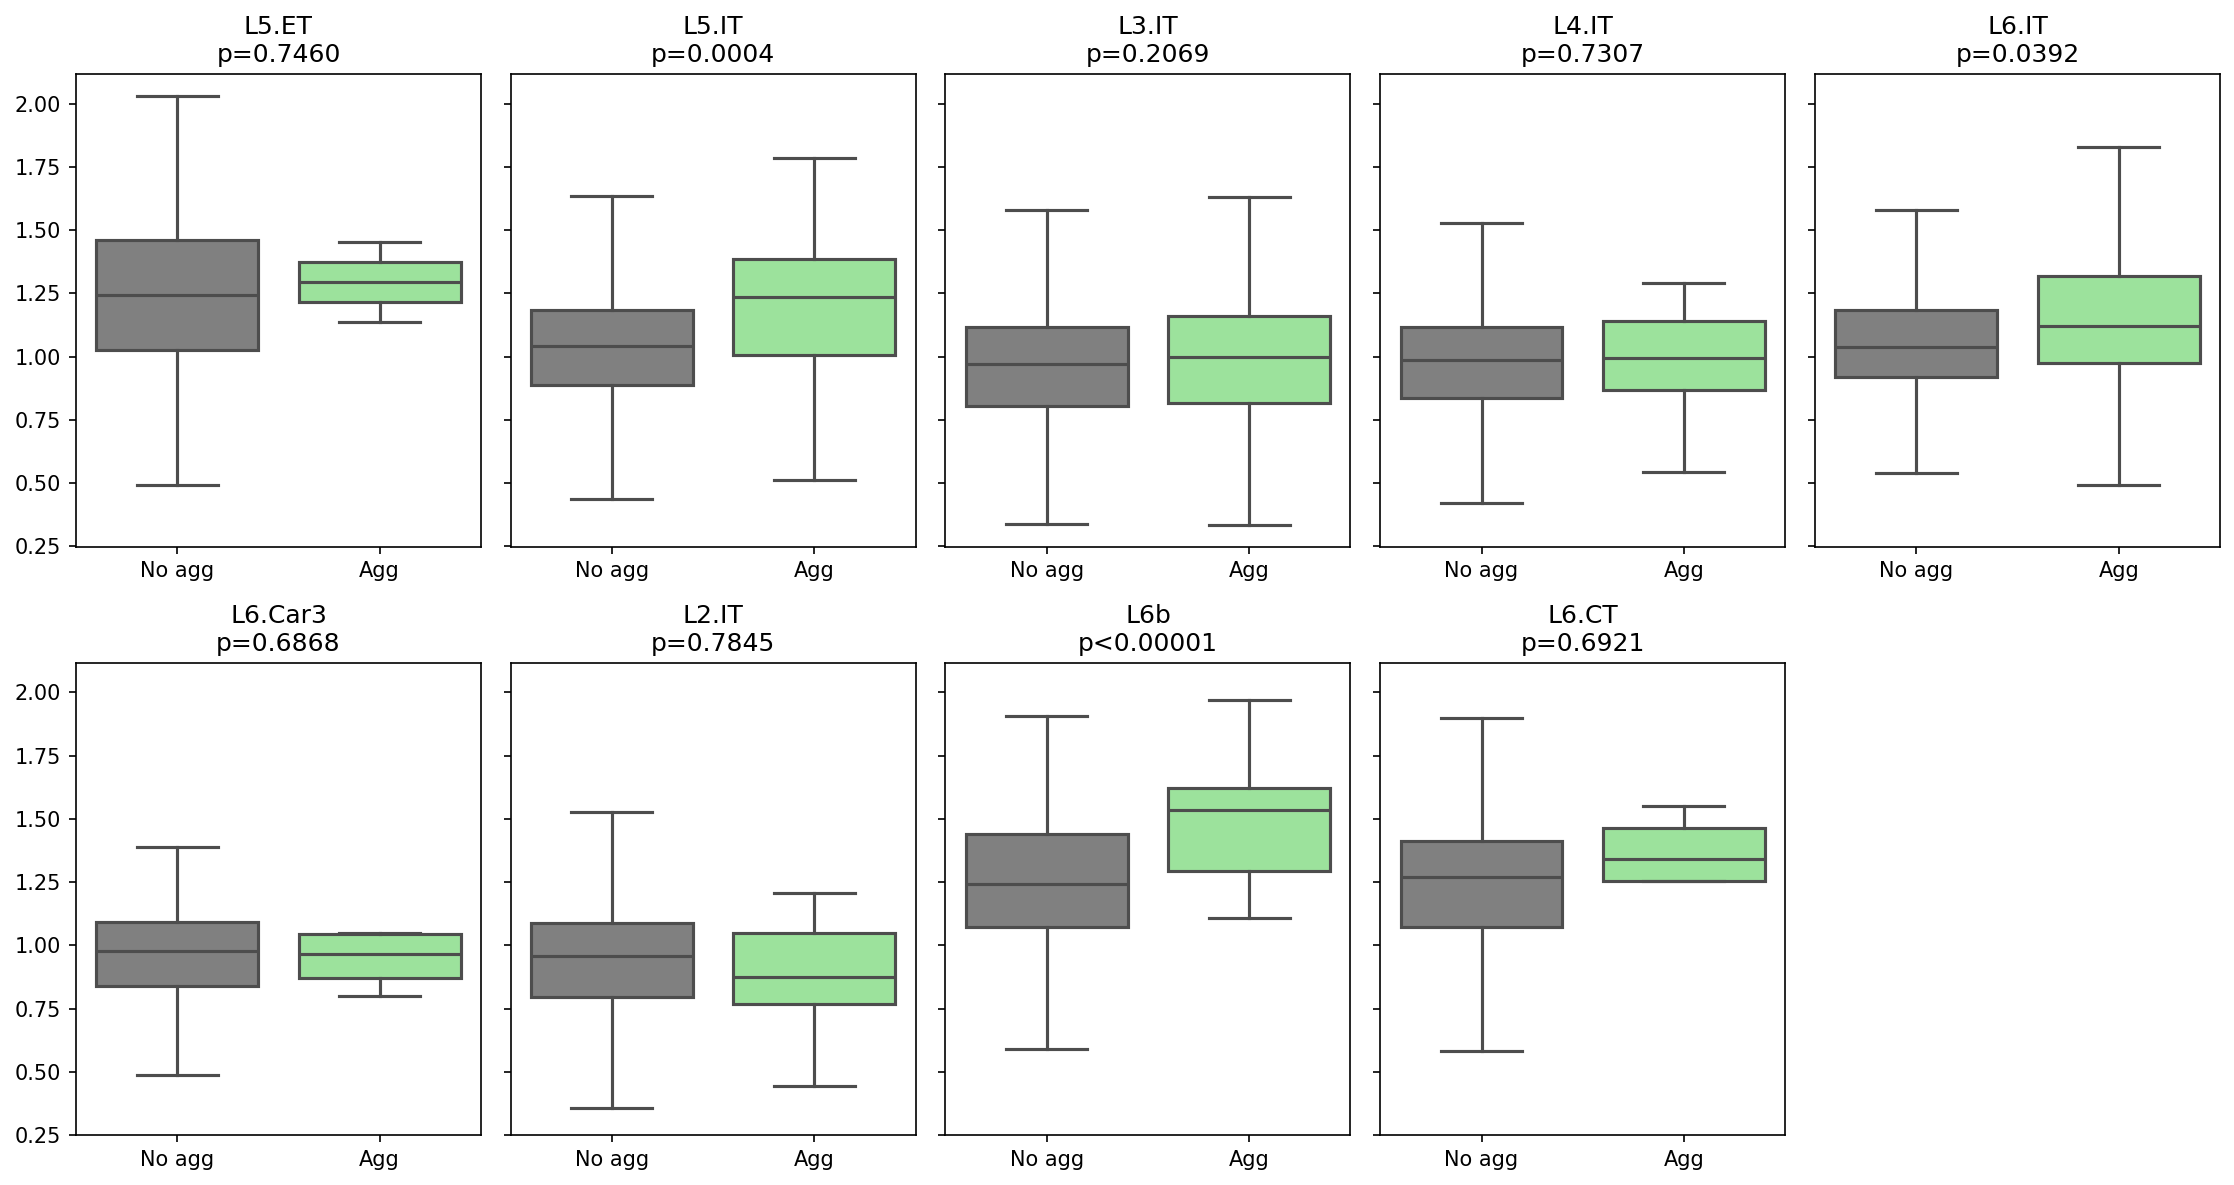

In [26]:

valid_clusters = [
    cl for cl in ucluster
    if (df_all.loc[df_all['cluster_names'] == cl, 'Agg'] == True).sum() > 0
]

ncols = 5
nrows = math.ceil(len(valid_clusters) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3*ncols, 4*nrows),
    dpi=150,
    sharey=True
    
)

axes = np.array(axes).flatten()

for ax, cl in zip(axes, valid_clusters):

    cl_df_all = df_all[df_all['cluster_names'] == cl].copy()

    no_agg = cl_df_all.loc[cl_df_all['Agg'] == False, 'm_h3k9_norm']
    agg    = cl_df_all.loc[cl_df_all['Agg'] == True, 'm_h3k9_norm']

    if len(no_agg) == 0 or len(agg) == 0:
        ax.set_visible(False)
        continue

    stat, pval = stats.ttest_ind(no_agg,agg,equal_var=False,nan_policy="omit")

    sns.boxplot(data=cl_df_all,x='Agg',y='m_h3k9_norm',showfliers=False,palette=['gray', 'lightgreen'], ax=ax)

    #sns.swarmplot(data=cl_df_all, x='Agg', y='m_gamma_norm', color='black', size=2, alpha=0.6, ax=ax)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No agg', 'Agg'])

    if pval > 1e-5:
        ax.set_title(f'{cl}\np={pval:.4f}')
    else:
        ax.set_title(f'{cl}\np<0.00001')

    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(valid_clusters):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [27]:
##################################################
#### FIGURE 6F: H3K9me3 and Inclusions and CAG
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/1340908327.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_across = df.groupby('CAG_bin')['m_h3k9_norm'].mean().reindex(bin_labels)
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/1340908327.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sem_across = df.groupby('CAG_bin')['m_h3k9_norm'].sem().reindex(bin_labels)


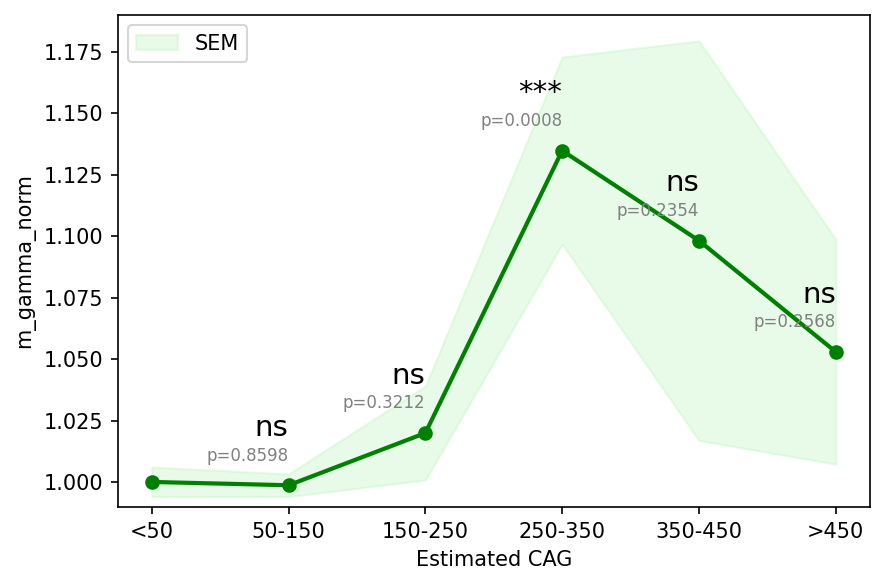

In [28]:
df = []

# Plot individual patient trajectories
for pt in upatientHD:
    df_pt = Exc5.obs[Exc5.obs['patient'] == pt].copy()

    baseline = df_pt.loc[df_pt['CAG_mut'] < 50, 'm_h3k9'].mean()
    df_pt['m_h3k9_norm'] = df_pt['m_h3k9'] / baseline
    df_pt['CAG_bin'] = pd.cut(df_pt['CAG_mut'], bins=bins, labels=bin_labels, right=False)
    df.append(df_pt[['patient','CAG_mut','CAG_bin','m_h3k9_norm', 'cluster_names']])

df = pd.concat(df)

# Compute mean ± SEM at the cell level
mean_across = df.groupby('CAG_bin')['m_h3k9_norm'].mean().reindex(bin_labels)
sem_across = df.groupby('CAG_bin')['m_h3k9_norm'].sem().reindex(bin_labels)

# Plot
plt.figure(figsize=(6,4), dpi=150)
plt.plot(bin_labels, mean_across, marker='o', color='green', linewidth=2)
plt.fill_between(bin_labels,
                 mean_across - sem_across,
                 mean_across + sem_across,
                 color='lightgreen', alpha=0.2, label='SEM')

# Reference bin = first one
ref_bin = bin_labels[0]
ref_values = df.loc[df['CAG_bin'] == ref_bin, 'm_h3k9_norm'].dropna()

# T-test against each other bin using cell-level data
for i, bin_lab in enumerate(bin_labels[1:], start=1):
    group_values = df.loc[df['CAG_bin'] == bin_lab, 'm_h3k9_norm'].dropna()
    if len(ref_values) > 1 and len(group_values) > 1:
        stat, pval = stats.ttest_ind(ref_values, group_values, equal_var=False)
        star = pval_to_star(pval)
        y_pos = mean_across.iloc[i] + 0.02
        plt.text(i, y_pos, star, ha='right', fontsize=14, color='black')
        plt.text(i, y_pos - 0.01, f"p={pval:.4f}", ha='right', fontsize=8, color='gray')

plt.ylabel("m_gamma_norm")
plt.xlabel("Estimated CAG")
plt.ylim(0.99, 1.19)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f'Figures/F6F.pdf')
plt.show()


In [29]:
##################################################
#### FIGURE 6H: H3K27ac and Inclusions
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


Global comparison Agg vs NoAgg: p = 0.2901


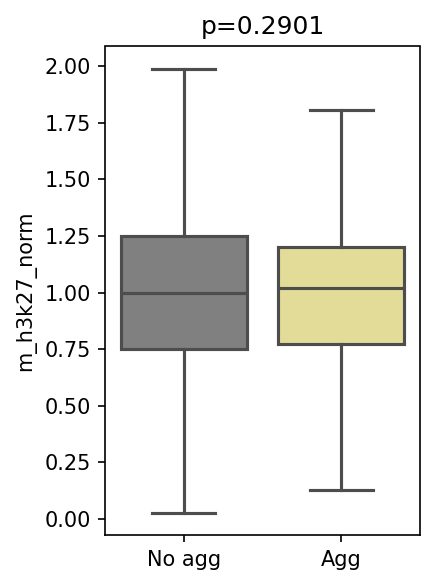

In [30]:
df_all = []

for pt in upatientHD:

    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
    
    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)
    baseline = df_pt.loc[df_pt['Agg']==False, 'm_h3k27'].median()
    df_pt['m_h3k27_norm'] = df_pt['m_h3k27'] / baseline 
    df_pt['patient'] = pt
    
    df_all.append(df_pt[['patient','Agg','m_h3k27_norm', 'cluster_names']])

df_all = pd.concat(df_all)

no_agg = df_all.loc[df_all['Agg'] == False, 'm_h3k27_norm']
agg    = df_all.loc[df_all['Agg'] == True, 'm_h3k27_norm']

stat, pval = stats.ttest_ind(no_agg, agg, equal_var=False, nan_policy="omit")

print(f"Global comparison Agg vs NoAgg: p = {pval:.4f}")

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_all, x='Agg', y='m_h3k27_norm',
                 showfliers=False, palette=['gray','khaki'])
#sns.swarmplot(data=df_all, x='Agg', y='m_h3k9_norm', color='black', size=2, alpha=0.6)

plt.ylabel("m_h3k27_norm")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
if pval>0.00001:
    plt.title(f'p={pval:.4f}')
else:
    plt.title(f'p<0.00001')
#plt.ylim(0,2.5)

plt.tight_layout()
plt.savefig('Figures/F6H_1.pdf')
plt.show()


In [31]:
##################################################
#### SUPPLEMENTARY FIGURE 16C: H3K27ac and Inclusions per donor
##################################################

Number of patients: 5
Paired t-test per patient median Agg vs NoAgg: p = 0.857628


/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

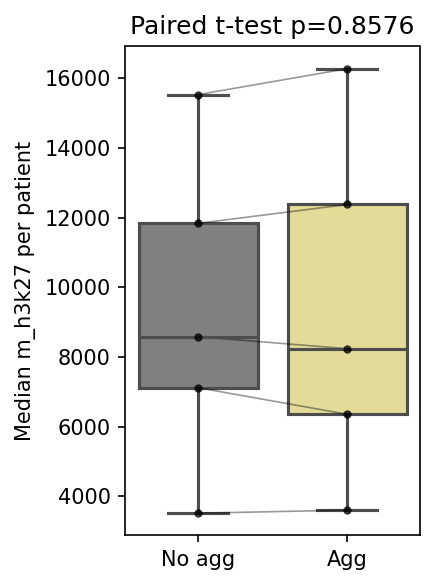

In [32]:
###PAIRED T TEST
agg_medians = []
noagg_medians = []

for pt in upatientHD:
    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)

    # Compute median for each condition within patient
    no_agg_median = df_pt.loc[df_pt['Agg'] == False, 'm_h3k27'].median()
    agg_median    = df_pt.loc[df_pt['Agg'] == True,  'm_h3k27'].median()
    
    # Only include patients with both conditions
    if not np.isnan(no_agg_median) and not np.isnan(agg_median):
        noagg_medians.append(no_agg_median)
        agg_medians.append(agg_median)

# Convert to arrays for t-test
noagg_medians = np.array(noagg_medians)
agg_medians = np.array(agg_medians)

# Paired t-test since values are matched per patient
stat, pval = stats.ttest_rel(noagg_medians, agg_medians, nan_policy="omit")

print("Number of patients:", len(noagg_medians))
print(f"Paired t-test per patient median Agg vs NoAgg: p = {pval:.6f}")

df_plot = pd.DataFrame({
    'NoAgg': noagg_medians,
    'Agg': agg_medians
}, index=upatientHD[:len(noagg_medians)])  # optional: match names

df_plot_melt = df_plot.reset_index().melt(id_vars='index', var_name='Condition', value_name='m_h3k27')

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_plot_melt, x='Condition', y='m_h3k27', 
                 showfliers=False, palette=['gray','khaki'])
sns.swarmplot(data=df_plot_melt, x='Condition', y='m_h3k27',
              color='black', size=4, alpha=0.8)

# optional: connect paired points
for i, row in df_plot.iterrows():
    plt.plot(['NoAgg','Agg'], row.values, color='black', alpha=0.4, linewidth=0.8)

plt.ylabel("Median m_h3k27 per patient")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
plt.title(f'Paired t-test p={pval:.4f}')
plt.tight_layout()
plt.savefig(f'Figures/F6J.pdf')

plt.show()


In [33]:
##################################################
#### SUPPLEMENTARY FIGURE 16I: H3K27ac and Inclusions per cell type
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

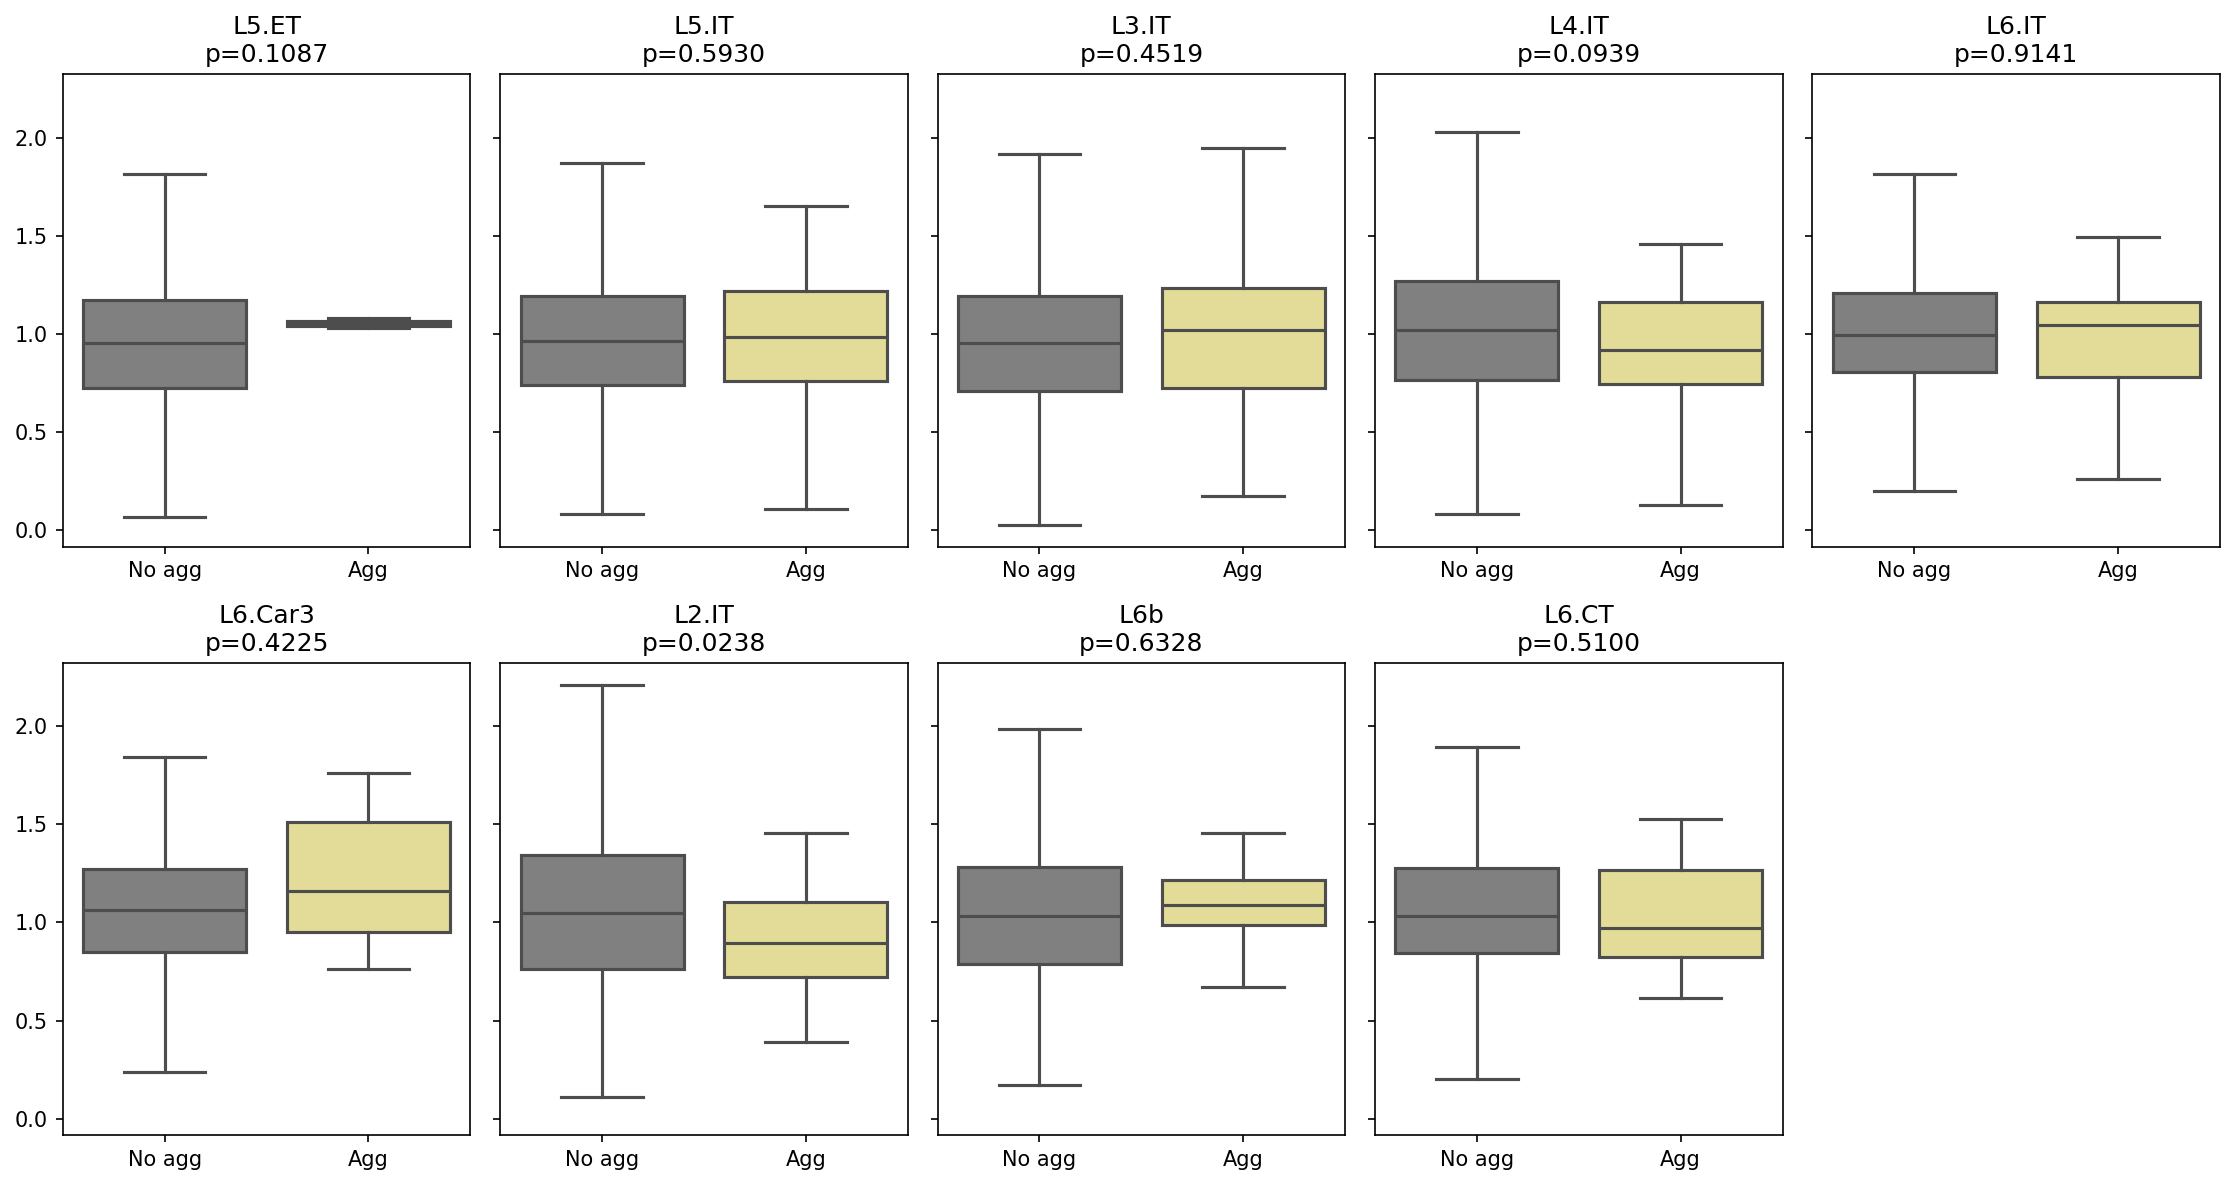

In [34]:
valid_clusters = [
    cl for cl in ucluster
    if (df_all.loc[df_all['cluster_names'] == cl, 'Agg'] == True).sum() > 0
]

ncols = 5
nrows = math.ceil(len(valid_clusters) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3*ncols, 4*nrows),
    dpi=150,
    sharey=True
    
)

axes = np.array(axes).flatten()

for ax, cl in zip(axes, valid_clusters):

    cl_df_all = df_all[df_all['cluster_names'] == cl].copy()

    no_agg = cl_df_all.loc[cl_df_all['Agg'] == False, 'm_h3k27_norm']
    agg    = cl_df_all.loc[cl_df_all['Agg'] == True, 'm_h3k27_norm']

    if len(no_agg) == 0 or len(agg) == 0:
        ax.set_visible(False)
        continue

    stat, pval = stats.ttest_ind(no_agg,agg,equal_var=False,nan_policy="omit")

    sns.boxplot(data=cl_df_all,x='Agg',y='m_h3k27_norm',showfliers=False,palette=['gray', 'khaki'], ax=ax)

    #sns.swarmplot(data=cl_df_all, x='Agg', y='m_gamma_norm', color='black', size=2, alpha=0.6, ax=ax)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No agg', 'Agg'])

    if pval > 1e-5:
        ax.set_title(f'{cl}\np={pval:.4f}')
    else:
        ax.set_title(f'{cl}\np<0.00001')

    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(valid_clusters):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [35]:
##################################################
#### FIGURE 6I: H3K27ac and CAG
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/1874108438.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_across = df.groupby('CAG_bin')['m_h3k27_norm'].mean().reindex(bin_labels)
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/1874108438.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sem_across = df.groupby('CAG_bin')['m_h3k27_norm'].sem().reindex(bin_labels)


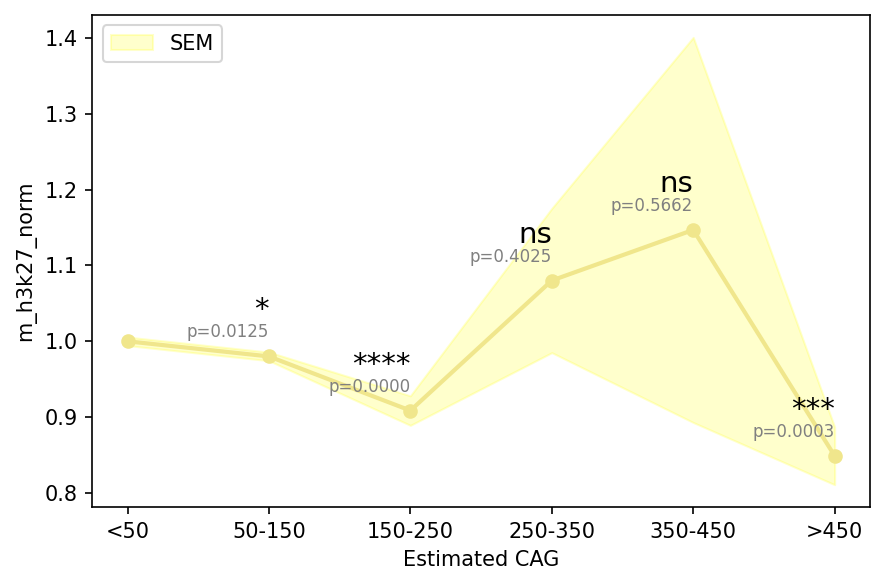

In [36]:
df = []

# Plot individual patient trajectories
for pt in upatientHD:
    df_pt = Exc5.obs[Exc5.obs['patient'] == pt].copy()

    baseline = df_pt.loc[df_pt['CAG_mut'] < 50, 'm_h3k27'].mean()
    df_pt['m_h3k27_norm'] = df_pt['m_h3k27'] / baseline
    df_pt['CAG_bin'] = pd.cut(df_pt['CAG_mut'], bins=bins, labels=bin_labels, right=False)
    df.append(df_pt[['patient','CAG_mut','CAG_bin','m_h3k27_norm', 'cluster_names']])

df = pd.concat(df)

# Compute mean ± SEM at the cell level
mean_across = df.groupby('CAG_bin')['m_h3k27_norm'].mean().reindex(bin_labels)
sem_across = df.groupby('CAG_bin')['m_h3k27_norm'].sem().reindex(bin_labels)

# Plot
plt.figure(figsize=(6,4), dpi=150)
plt.plot(bin_labels, mean_across, marker='o', color='khaki', linewidth=2)
plt.fill_between(bin_labels,
                 mean_across - sem_across,
                 mean_across + sem_across,
                 color='yellow', alpha=0.2, label='SEM')

# Reference bin = first one
ref_bin = bin_labels[0]
ref_values = df.loc[df['CAG_bin'] == ref_bin, 'm_h3k27_norm'].dropna()

# T-test against each other bin using cell-level data
for i, bin_lab in enumerate(bin_labels[1:], start=1):
    group_values = df.loc[df['CAG_bin'] == bin_lab, 'm_h3k27_norm'].dropna()
    if len(ref_values) > 1 and len(group_values) > 1:
        stat, pval = stats.ttest_ind(ref_values, group_values, equal_var=False)
        star = pval_to_star(pval)
        y_pos = mean_across.iloc[i] + 0.05
        plt.text(i, y_pos, star, ha='right', fontsize=14, color='black')
        plt.text(i, y_pos - 0.025, f"p={pval:.4f}", ha='right', fontsize=8, color='gray')

plt.ylabel("m_h3k27_norm")
plt.xlabel("Estimated CAG")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f'Figures/F6I.pdf')
plt.show()


In [37]:
##################################################
#### SUPPLEMENTARY FIGURE 16E: Lipofuscin granules and Inclusions
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

Number of patients: 5
Paired t-test per patient median Agg vs NoAgg: p = 0.008276


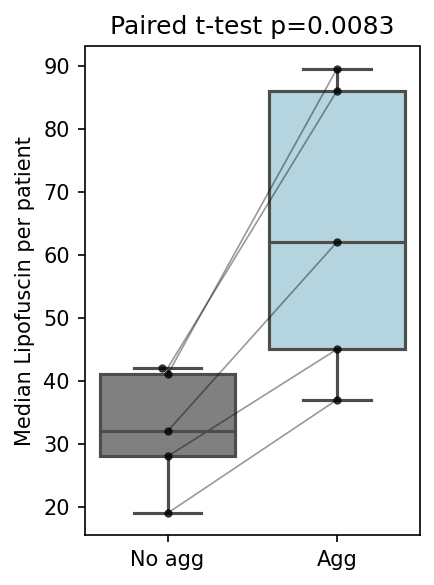

In [38]:
###PAIRED T TEST
agg_medians = []
noagg_medians = []

for pt in upatientHD:
    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
    
    df_pt['Agg'] = df_pt['Agg'].fillna(False).astype(bool)
    no_agg_median = df_pt.loc[df_pt['Agg'] == False, 'lipo'].median()
    agg_median    = df_pt.loc[df_pt['Agg'] == True,  'lipo'].median()
    
    # Only include patients with both conditions
    if not np.isnan(no_agg_median) and not np.isnan(agg_median):
        noagg_medians.append(no_agg_median)
        agg_medians.append(agg_median)

# Convert to arrays for t-test
noagg_medians = np.array(noagg_medians)
agg_medians = np.array(agg_medians)

# Paired t-test since values are matched per patient
stat, pval = stats.ttest_rel(noagg_medians, agg_medians, nan_policy="omit")

print("Number of patients:", len(noagg_medians))
print(f"Paired t-test per patient median Agg vs NoAgg: p = {pval:.6f}")

df_plot = pd.DataFrame({
    'NoAgg': noagg_medians,
    'Agg': agg_medians
}, index=upatientHD[:len(noagg_medians)])  # optional: match names

df_plot_melt = df_plot.reset_index().melt(id_vars='index', var_name='Condition', value_name='Median_lipo')

plt.figure(figsize=(3,4), dpi=150)
ax = sns.boxplot(data=df_plot_melt, x='Condition', y='Median_lipo', 
                 showfliers=False, palette=['gray','lightblue'])
sns.swarmplot(data=df_plot_melt, x='Condition', y='Median_lipo',
              color='black', size=4, alpha=0.8)

# optional: connect paired points
for i, row in df_plot.iterrows():
    plt.plot(['NoAgg','Agg'], row.values, color='black', alpha=0.4, linewidth=0.8)

plt.ylabel("Median Lipofuscin per patient")
plt.xlabel('')
plt.xticks([0,1], ['No agg','Agg'])
plt.title(f'Paired t-test p={pval:.4f}')
plt.tight_layout()
plt.savefig(f'Figures/F6B.pdf')

plt.show()


In [39]:
##################################################
#### SUPPLEMENTARY FIGURE 16F: Lipofuscin granules and CAG
##################################################

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/406535129.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bin = df_pt.groupby('CAG_bin')['lipo'].median().reset_index()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/406535129.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bin = df_pt.groupby('CAG_bin')['lipo'].median().reset_index()
/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_66847/406535129.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain 

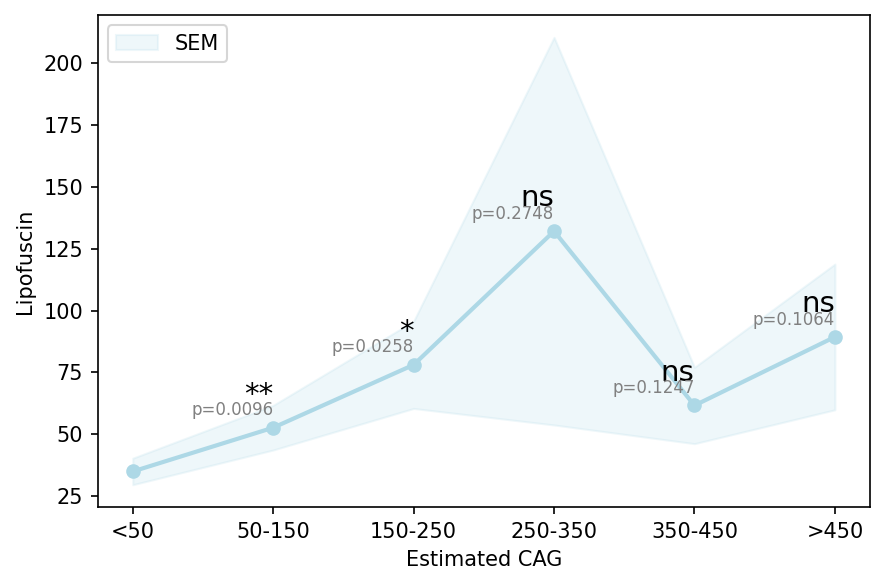

In [40]:
#Median of each patient and paired T-tests

df_all = []

for pt in upatientHD:
    df_pt = Exc.obs[Exc.obs['patient'] == pt].copy()
    df_pt['CAG_bin'] = pd.cut(df_pt['CAG_length'], bins=bins, labels=bin_labels, right=False)
    
    # Compute median per patient per bin
    df_bin = df_pt.groupby('CAG_bin')['lipo'].median().reset_index()
    df_bin['patient'] = pt
    df_all.append(df_bin)
    

df_all = pd.concat(df_all)
    

# Compute mean ± SEM across patients
mean_across = df_all.groupby('CAG_bin')['lipo'].mean().reindex(bin_labels)
sem_across  = df_all.groupby('CAG_bin')['lipo'].sem().reindex(bin_labels)

# Plot
plt.figure(figsize=(6,4), dpi=150)
plt.plot(bin_labels, mean_across, marker='o', color='lightblue', linewidth=2)
plt.fill_between(bin_labels,
                 mean_across - sem_across,
                 mean_across + sem_across,
                 color='lightblue', alpha=0.2, label='SEM')

# Reference bin = first one
ref_bin = bin_labels[0]
ref_values = df_all.loc[df_all['CAG_bin'] == ref_bin, 'lipo'].dropna()

# T-test at patient level
for i, bin_lab in enumerate(bin_labels[1:], start=1):
    group_values = df_all.loc[df_all['CAG_bin'] == bin_lab, 'lipo'].dropna()
    # only compare patients that have values in both bins
    common_patients = np.intersect1d(
        df_all.loc[df_all['CAG_bin']==ref_bin, 'patient'],
        df_all.loc[df_all['CAG_bin']==bin_lab, 'patient']
    )
    ref_vals = df_all.loc[(df_all['CAG_bin']==ref_bin) & (df_all['patient'].isin(common_patients)), 'lipo']
    grp_vals = df_all.loc[(df_all['CAG_bin']==bin_lab) & (df_all['patient'].isin(common_patients)), 'lipo']
    
    if len(ref_vals) > 1 and len(grp_vals) > 1:
        stat, pval = stats.ttest_rel(ref_vals, grp_vals, nan_policy='omit')  # paired per patient
        star = pval_to_star(pval)
        y_pos = mean_across.iloc[i] + 10
        plt.text(i, y_pos, star, ha='right', fontsize=14, color='black')
        plt.text(i, y_pos - 5, f"p={pval:.4f}", ha='right', fontsize=8, color='gray')

plt.ylabel("Lipofuscin")
plt.xlabel("Estimated CAG")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(f'Figures/SF16C.pdf')

plt.show()


In [41]:
##################################################
#### SUPPLEMENTARY FIGURE 16J: Lipofuscin granules and Inclusions
##################################################

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

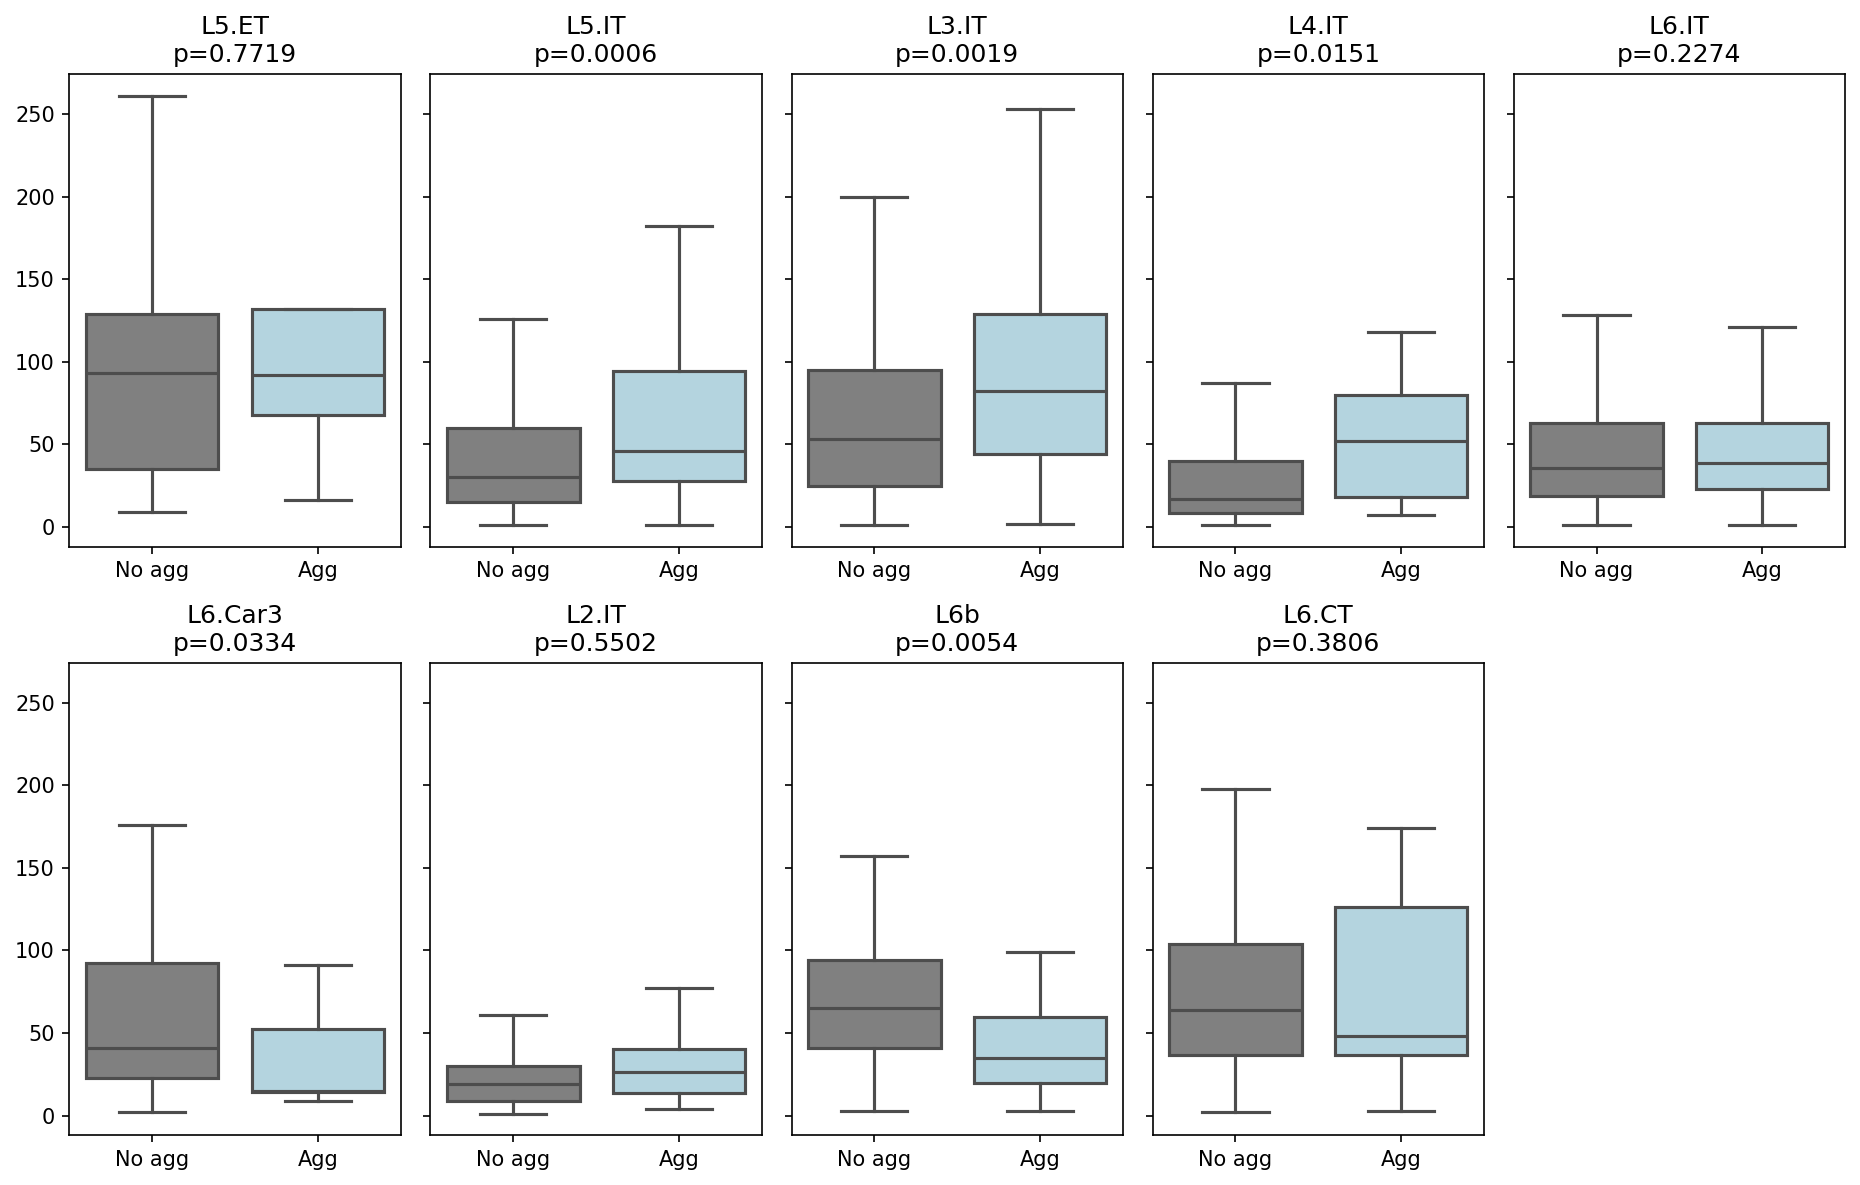

In [42]:
df_all = Exc.obs.copy()


valid_clusters = [
    cl for cl in ucluster
    if (df_all.loc[df_all['cluster_names'] == cl, 'Agg'] == True).sum() > 0
]

ncols = 5
nrows = math.ceil(len(valid_clusters) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(2.5*ncols, 4*nrows),
    dpi=150,
    sharey=True
    
)

axes = np.array(axes).flatten()

for ax, cl in zip(axes, valid_clusters):

    cl_df_all = df_all[df_all['cluster_names'] == cl].copy()

    no_agg = cl_df_all.loc[cl_df_all['Agg'] == False, 'lipo']
    agg    = cl_df_all.loc[cl_df_all['Agg'] == True, 'lipo']

    if len(no_agg) == 0 or len(agg) == 0:
        ax.set_visible(False)
        continue

    stat, pval = stats.ttest_ind(no_agg,agg,equal_var=False,nan_policy="omit")

    sns.boxplot(data=cl_df_all,x='Agg',y='lipo',showfliers=False,palette=['gray', 'lightblue'], ax=ax)

    #sns.swarmplot(data=cl_df_all, x='Agg', y='m_gamma_norm', color='black', size=2, alpha=0.6, ax=ax)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No agg', 'Agg'])

    if pval > 1e-5:
        ax.set_title(f'{cl}\np={pval:.4f}')
    else:
        ax.set_title(f'{cl}\np<0.00001')

    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(valid_clusters):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()